# Section 00 - Getting Ready

In [27]:
import pandas as pd
import plotnine as p9
import statsmodels.api as sm
import statsmodels.formula.api as smf
from plotnine import *

# Section 01 - Adjusting for confounding variables - Yeast QTL

Recall the yeast dataset from the previous exercises and lecture, which analyses the genetic determinants
of yeast growth rates. We look at three genes, for simplicity called A, B and C, of which each yeast can
have one of two variants: “wild” or “lab”. We want to determine whether the different variants of these
genes are associated with differences in growth rate. In particular, we consider once again the question:
Does the gene-B variant still associate with growth when conditioned on the gene-A variant?
Here is the code to load the data and the plot of the data:

In [25]:
growth_analysis = (pd.read_csv("../Datasets/Exercise2_datasets/Exercise7DATA.csv", sep = '\t')
.rename(columns = {'gene_5211': 'gene_A',
'gene_5091': 'gene_B',
'gene_1653': 'gene_C'})
.loc[:, ['strain', 'growth_rate', 'gene_A', 'gene_B', 'gene_C']])
growth_analysis.head()

,strain,growth_rate,gene_A,gene_B,gene_C
0,seg_01B,6.720447,False,False,True
1,seg_01C,7.429273,False,False,True
2,seg_01D,6.905589,True,True,False
3,seg_02B,4.924324,False,True,False
4,seg_02C,4.413402,False,False,True


In [26]:
growth_analysis['gene_A'] = pd.Categorical(growth_analysis['gene_A'])

/opt/anaconda3/lib/python3.13/site-packages/plotnine/layer.py:293: PlotnineWarning: stat_boxplot : Removed 4 rows containing non-finite values.


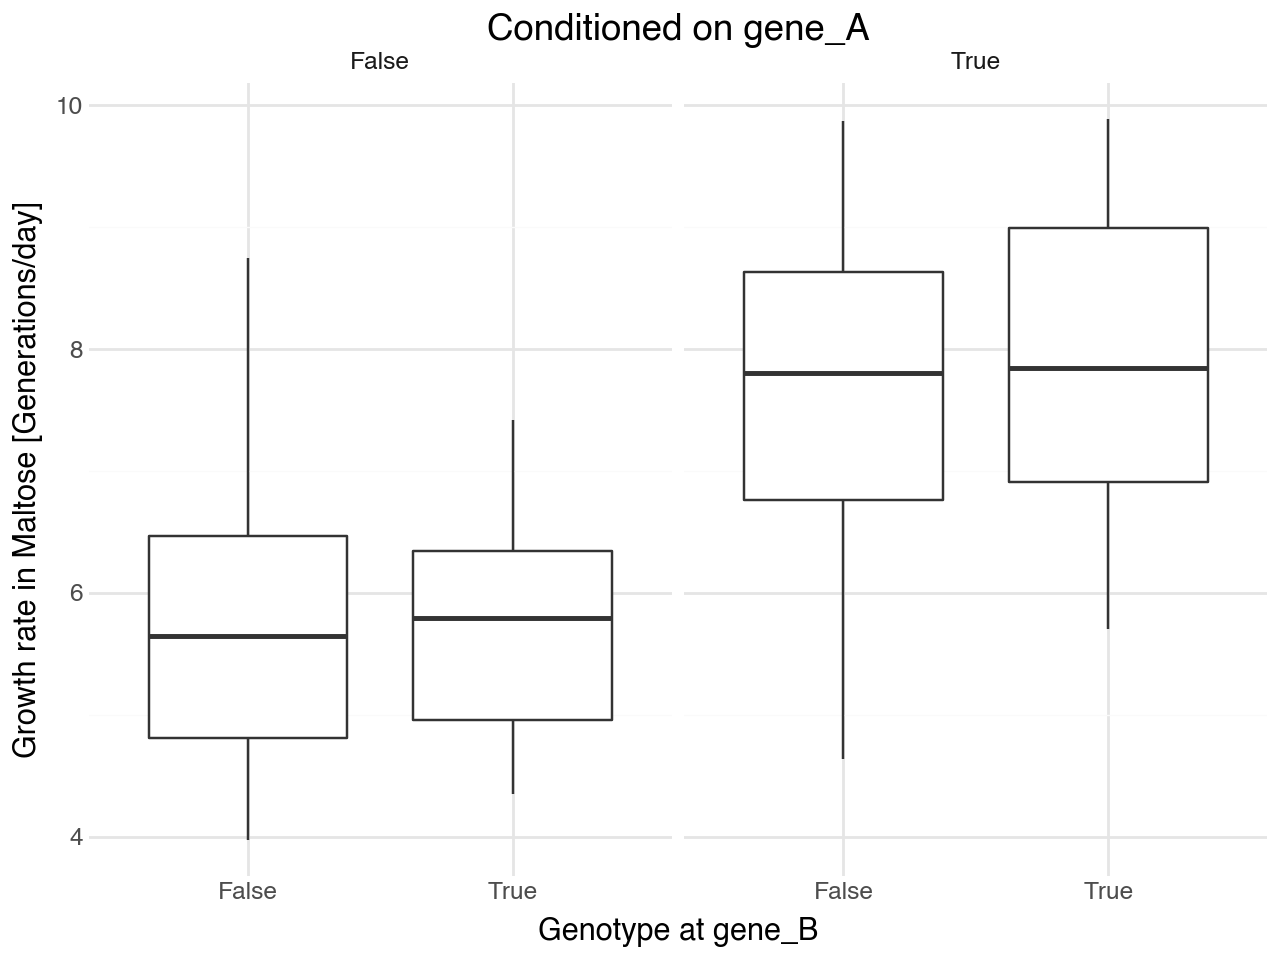

In [28]:
(
    ggplot(growth_analysis, aes('gene_B', 'growth_rate')) +
    geom_boxplot() +
    facet_wrap('gene_A') +
    xlab(f"Genotype at gene_B") +
    ylab("Growth rate in Maltose [Generations/day]") +
    labs(title = "Conditioned on gene_A") +
    theme_minimal()
)

1. Run a linear model predicting the growth given the genotypes of both markers and interpret the result.
Call this model full. Observe that the distribution of the residuals mildly deviate from a Gaussian. We
will not worry for this. Using summary() comment on the full model fit and conclude.

In [33]:
full = smf.ols('growth_rate ~ gene_A + gene_B', data = growth_analysis).fit()
residuals = full.resid

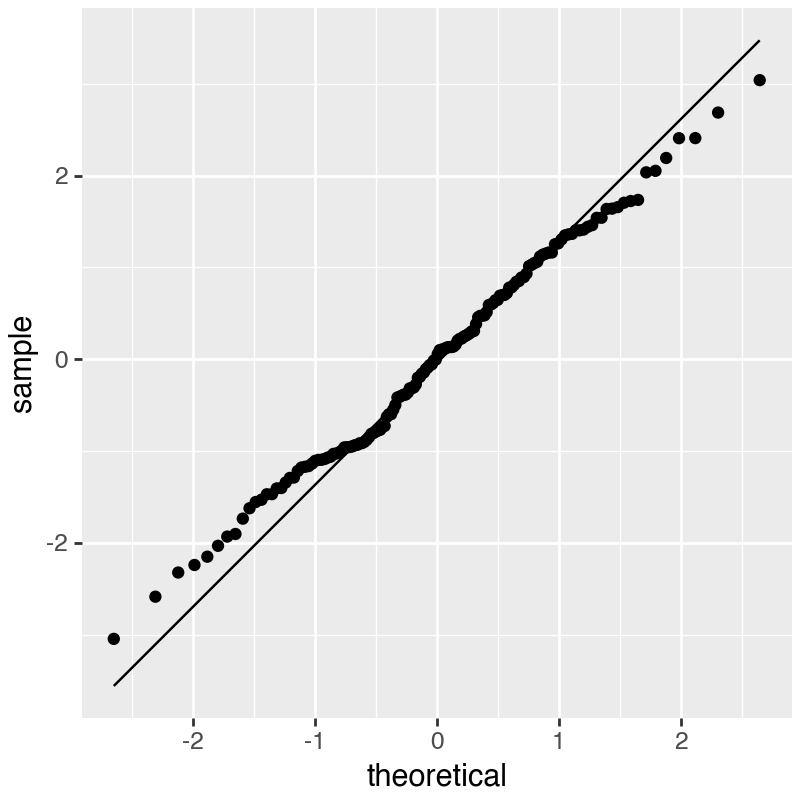

In [35]:
df_resid = pd.DataFrame({'resid':residuals})

(
    ggplot(df_resid, aes(sample = 'resid')) + 
    geom_qq() + 
    geom_qq_line() + 
    theme(figure_size=(4,4))
)

In [36]:
full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            growth_rate   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.428
Method:                 Least Squares   F-statistic:                     58.29
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.74e-19
Time:                        14:36:04   Log-Likelihood:                -241.38
No. Observations:                 154   AIC:                             488.8
Df Residuals:                     151   BIC:                             497.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          5.7064      0.151     37.809      0.000       5.408       6.005
gene_A[T.True]     1.9743      0.201      9.834      0.000       1.578       2.371
gene_B[T.True]     0.1747      0.201      0.871      0.385      -0.222       0.571
==============================================================================
Omnibus:                        1.432   Durbin-Watson:                   1.916
Prob(Omnibus):                  0.489   Jarque-Bera (JB):                1.282
Skew:                           0.069   Prob(JB):                        0.527
Kurtosis:                       2.575   Cond. No.                         3.16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

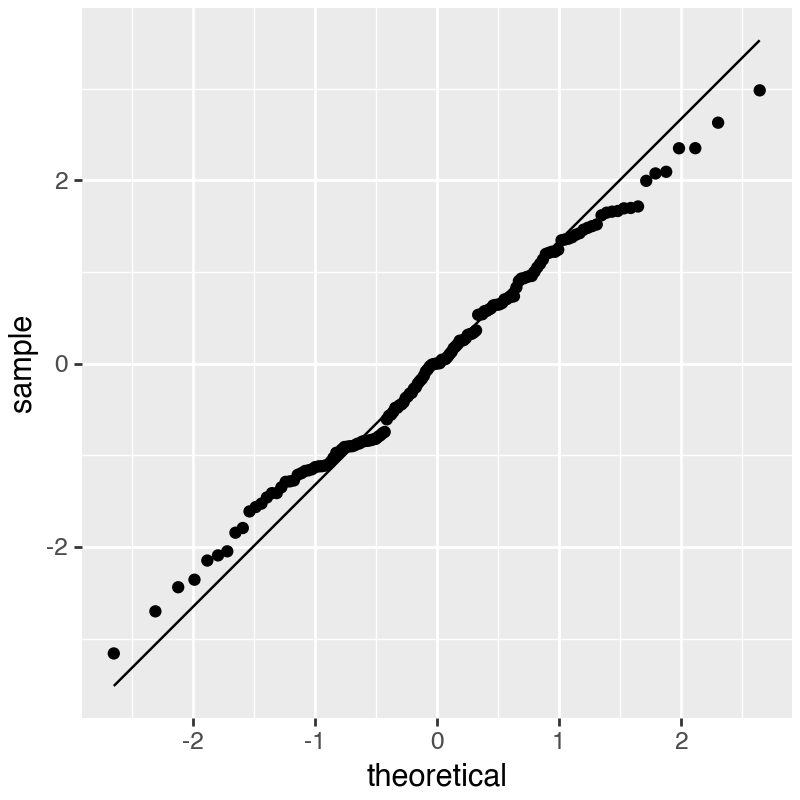

In [41]:
reduced = smf.ols('growth_rate ~ gene_A', data = growth_analysis).fit()
redi_reduced = reduced.resid

df_reduced = pd.DataFrame({'resid': redi_reduced})

(
    ggplot(df_reduced, aes(sample = 'resid')) +
    geom_qq() + 
    geom_qq_line() +
    theme(figure_size= (4,4))
)

Now runnning ANOVA analysis; our null hypothesis is:

$H_0$ = adding the genotype information of gene_B does not improve the model. 

In [47]:
from statsmodels.stats.anova import anova_lm

anova_result = anova_lm(reduced,full)

anova_result

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,152.0,208.275376,0.0,NaN,NaN,NaN
1,151.0,207.233953,1.0,1.041423,0.758827,0.385079


The probability under the null hypothesis of an F statistic as extreme as the one observed here is rather
high (> 0.05) so we would not reject the null hypothesis.

Thus, the ANOVA approach (here) and the t-test on the parameter of the full model lead to the same
conclusion.

-------

# Section 02 - Non-linearity

Load the “lm_nonlin.txt” dataset with the following code, adapted to your local folder. We find that y
correlates with x and z, bu

In [49]:
df = pd.read_csv('../Datasets/Exercise11/lm_nonlin.txt', sep = '\t')
df.head()

,x,y,z
0,1.252117,5.772922,0.704380
1,0.254841,1.019366,0.552330
2,1.847125,18.740481,1.347555
3,-0.248480,8.478449,0.937754
4,2.204449,38.509134,1.978237


1. First address this question with an appropriate linear regression but without performing any diagnostic
plot. Which regression do you perform? What does this analysis indicate?

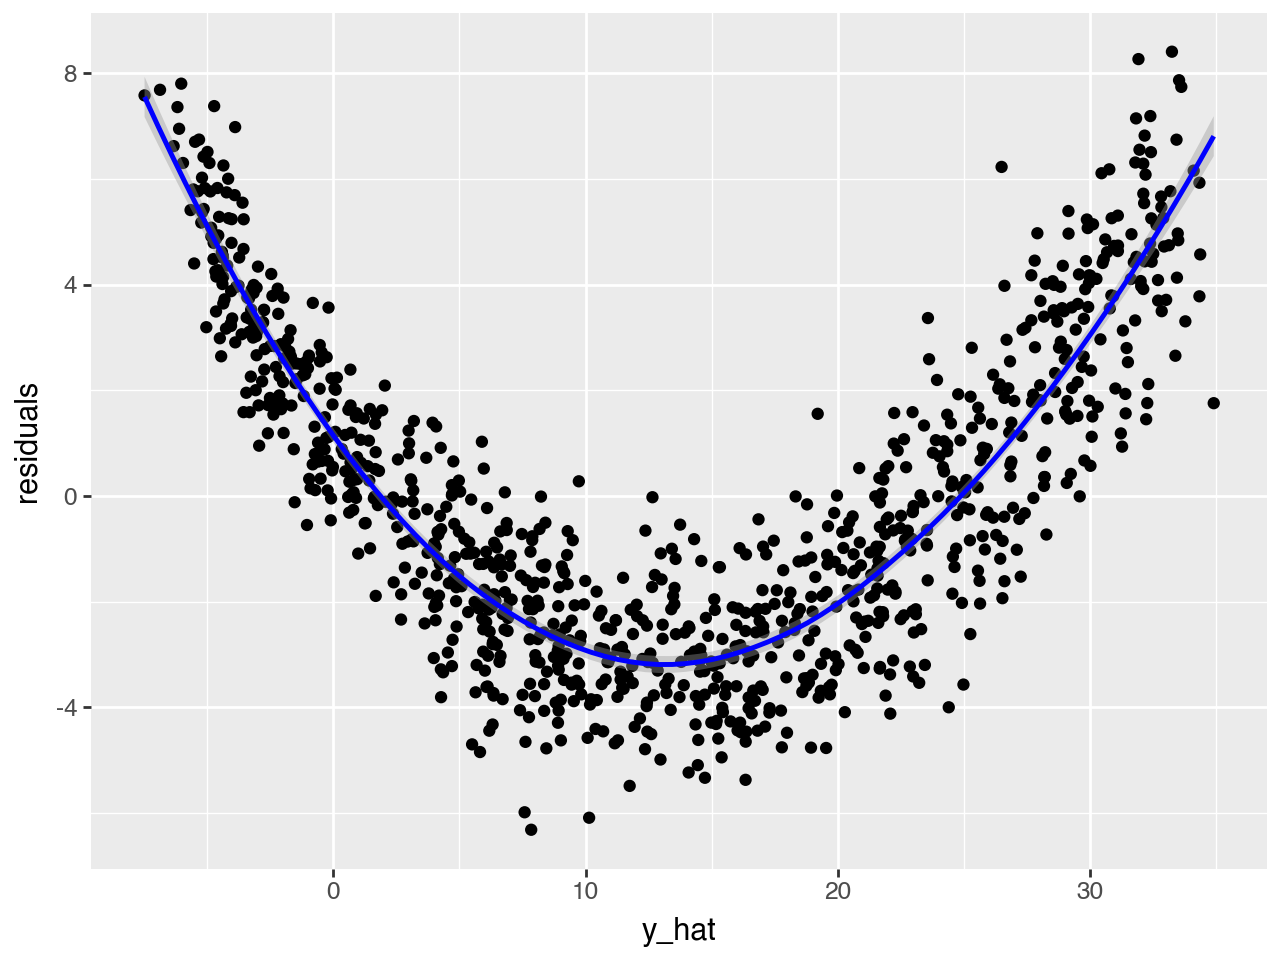

In [58]:
xyz_model = smf.ols('y ~ x + z', data = df).fit()


residuals_df = pd.DataFrame({'y_hat': xyz_model.fittedvalues, 'residuals': xyz_model.resid})

(
    ggplot(residuals_df, aes('y_hat', 'residuals')) +
    geom_point() +
    geom_smooth(method = 'loess', color = 'blue')
)

3. Through plotting, investigate graphically the relationship between the response variable y and the
explanatory variables x and z. Is there any transformation of the explanatory variable(s) you would
suggest?

Plot y against each explanatory variable:

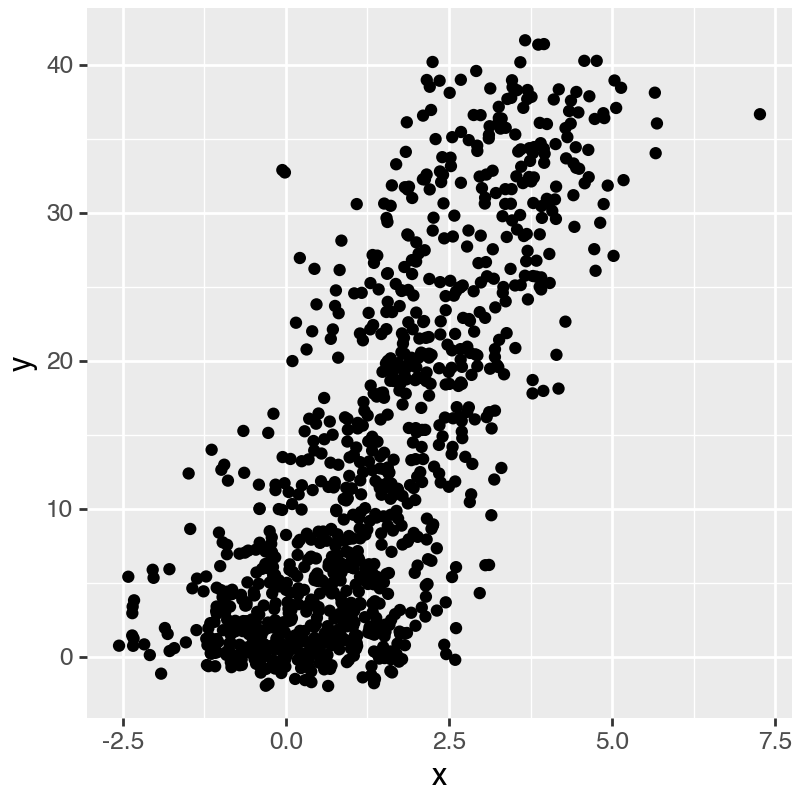

In [60]:
(
    ggplot(df, aes('x', 'y')) +
    geom_point() +
    theme(figure_size= (4,4))
)

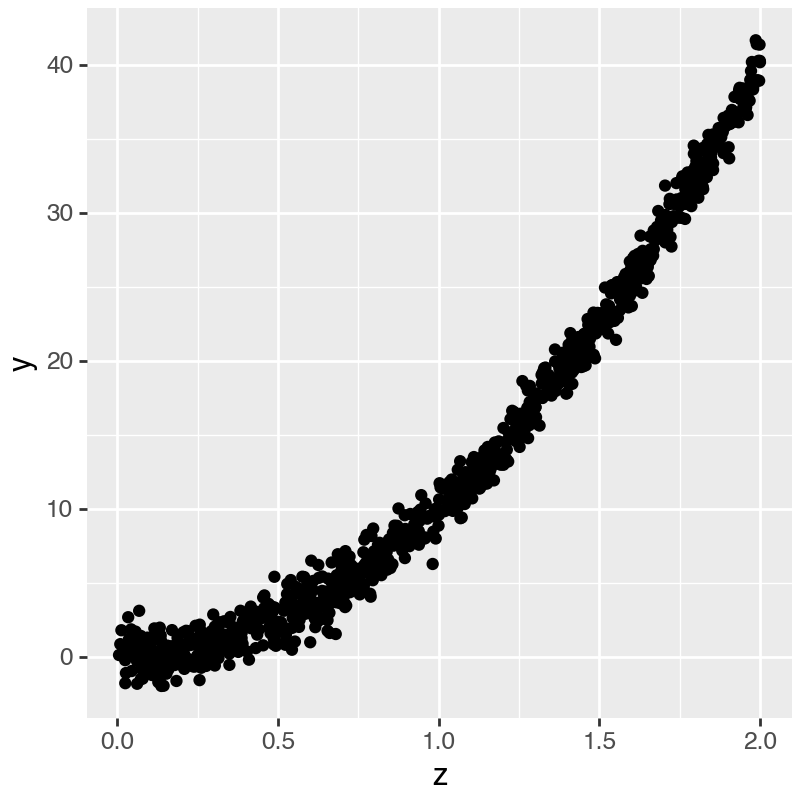

In [61]:
(
    ggplot(df, aes('z', 'y')) +
    geom_point() +
    theme(figure_size= (4,4))
)

4. Perform the linear regression against the transformed variable(s). What do you now conclude?

We transform z into z^2 and regress y against x and z^2:

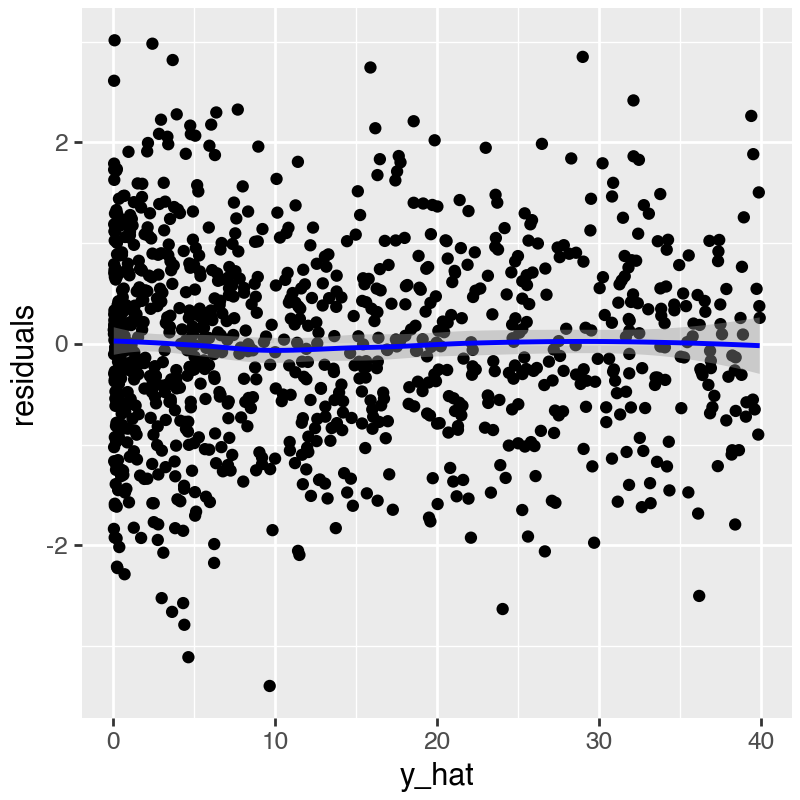

In [64]:
df['z_2'] = df['z']**2
xyz_model2 = smf.ols('y ~ x + z_2', data = df).fit()

residuals_df = pd.DataFrame({
    'y_hat' : xyz_model2.fittedvalues,
    'residuals' : xyz_model2.resid
})

(
    ggplot(residuals_df, aes('y_hat', 'residuals')) + 
    geom_point() + 
    geom_smooth(method = 'loess', color = 'blue') + 
    theme(figure_size=(4,4))
)

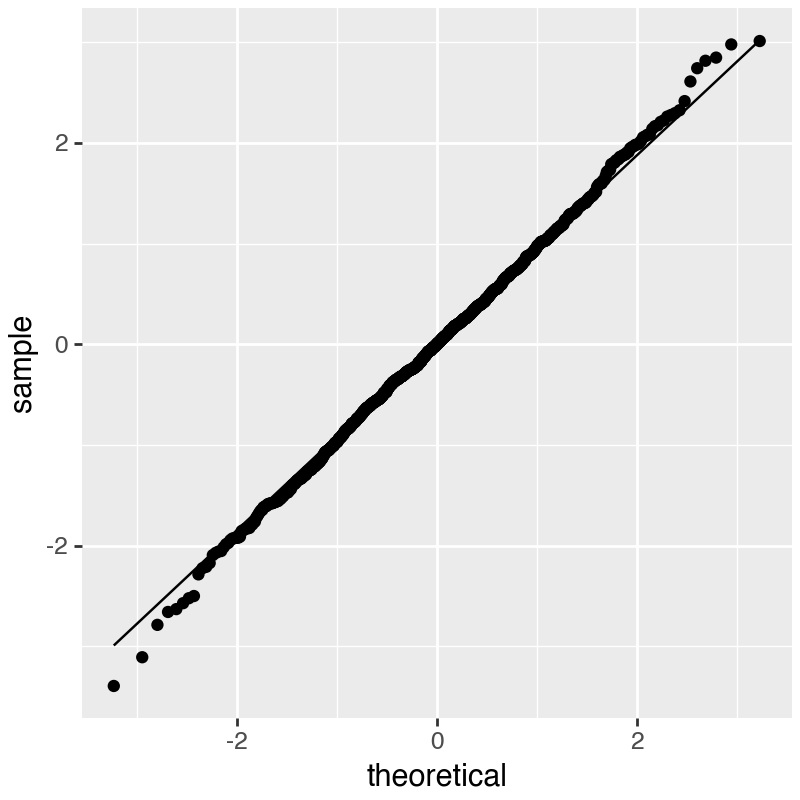

In [67]:
df_resid = pd.DataFrame({'resid':xyz_model2.resid})

(
    ggplot(df_resid, aes(sample = 'resid')) + 
    geom_qq() + 
    geom_qq_line() + 
    theme(figure_size= (4,4))
)

In [68]:
xyz_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.993
Method:                 Least Squares   F-statistic:                 7.562e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        15:13:31   Log-Likelihood:                -1386.1
No. Observations:                1000   AIC:                             2778.
Df Residuals:                     997   BIC:                             2793.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0499      0.046      1.095      0.274      -0.040       0.139
x             -0.0101      0.030     -0.333      0.739      -0.070       0.050
z_2            9.9815      0.040    251.125      0.000       9.904      10.059
==============================================================================
Omnibus:                        0.973   Durbin-Watson:                   1.972
Prob(Omnibus):                  0.615   Jarque-Bera (JB):                0.851
Skew:                           0.011   Prob(JB):                        0.654
Kurtosis:                       3.141   Cond. No.                         4.78
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The fit supports that y is linearly independent of x given z^2. Therefore, we can conclude that y is
statistically independent x given z.

--------

# Section 03 - Adjusting for confounding variables - Iris dataset

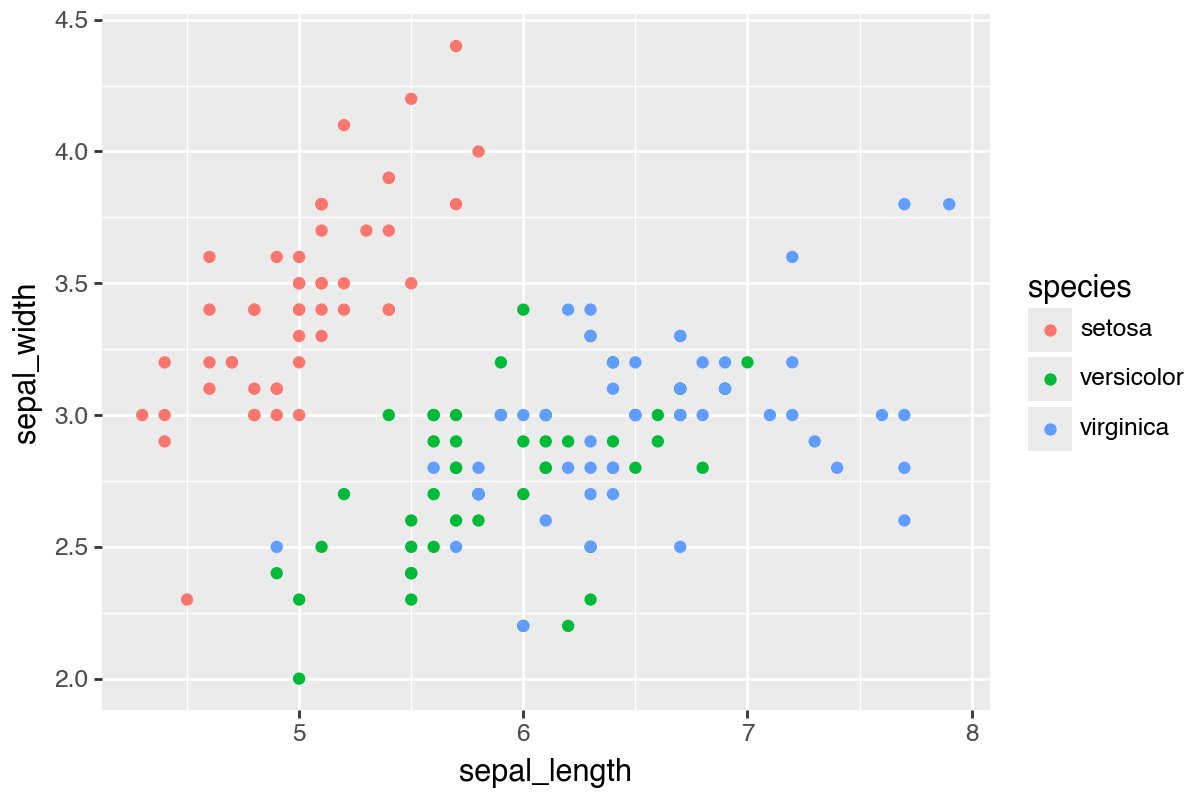

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [72]:
import seaborn as sns

iris = sns.load_dataset('iris')

display(
(
    ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
    geom_point() + 
    theme(figure_size=(6,4))
)
)
iris.head()

1. Fit three linear models predicting Sepal.Width from Sepal.Length: the base model that simply
predicts sepal width from sepal length, one where you use the species as a covariate in linear regression
(i.e., different intercept for different species) and one where you use separate slopes and intercepts for
different species by using the * operator in sm.ols: "sepal_width ~ sepal_length * species".

In [73]:
iris_model1 = smf.ols('sepal_width ~ sepal_length', data = iris).fit()
iris_model2 = smf.ols('sepal_width ~ sepal_length + species', data = iris).fit()
iris_model3 = smf.ols('sepal_width ~ sepal_length * species', data = iris).fit()

In [74]:
iris_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sepal_width   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.074
Date:                Wed, 11 Feb 2026   Prob (F-statistic):              0.152
Time:                        15:18:01   Log-Likelihood:                -86.732
No. Observations:                 150   AIC:                             177.5
Df Residuals:                     148   BIC:                             183.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4189      0.254     13.484      0.000       2.918       3.920
sepal_length    -0.0619      0.043     -1.440      0.152      -0.147       0.023
==============================================================================
Omnibus:                        2.474   Durbin-Watson:                   1.263
Prob(Omnibus):                  0.290   Jarque-Bera (JB):                1.994
Skew:                           0.243   Prob(JB):                        0.369
Kurtosis:                       3.288   Cond. No.                         43.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [75]:
iris_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sepal_width   R-squared:                       0.569
Model:                            OLS   Adj. R-squared:                  0.560
Method:                 Least Squares   F-statistic:                     64.32
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           1.46e-26
Time:                        15:18:16   Log-Likelihood:                -24.609
No. Observations:                 150   AIC:                             57.22
Df Residuals:                     146   BIC:                             69.26
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=========================================================================================
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 1.6765      0.235      7.123      0.000       1.211       2.142
species[T.versicolor]    -0.9834      0.072    -13.644      0.000      -1.126      -0.841
species[T.virginica]     -1.0075      0.093    -10.798      0.000      -1.192      -0.823
sepal_length              0.3499      0.046      7.557      0.000       0.258       0.441
==============================================================================
Omnibus:                        3.680   Durbin-Watson:                   1.902
Prob(Omnibus):                  0.159   Jarque-Bera (JB):                3.253
Skew:                          -0.269   Prob(JB):                        0.197
Kurtosis:                       3.481   Cond. No.                         64.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [76]:
iris_model3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            sepal_width   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     47.53
Date:                Wed, 11 Feb 2026   Prob (F-statistic):           7.78e-29
Time:                        15:18:46   Log-Likelihood:                -14.671
No. Observations:                 150   AIC:                             41.34
Df Residuals:                     144   BIC:                             59.41
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
======================================================================================================
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -0.5694      0.554     -1.028      0.306      -1.664       0.525
species[T.versicolor]                  1.4416      0.713      2.022      0.045       0.032       2.851
species[T.virginica]                   2.0157      0.686      2.938      0.004       0.660       3.372
sepal_length                           0.7985      0.110      7.235      0.000       0.580       1.017
sepal_length:species[T.versicolor]    -0.4788      0.134     -3.582      0.000      -0.743      -0.215
sepal_length:species[T.virginica]     -0.5666      0.126     -4.490      0.000      -0.816      -0.317
==============================================================================
Omnibus:                        1.116   Durbin-Watson:                   2.110
Prob(Omnibus):                  0.572   Jarque-Bera (JB):                0.903
Skew:                          -0.188   Prob(JB):                        0.637
Kurtosis:                       3.050   Cond. No.                         322.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

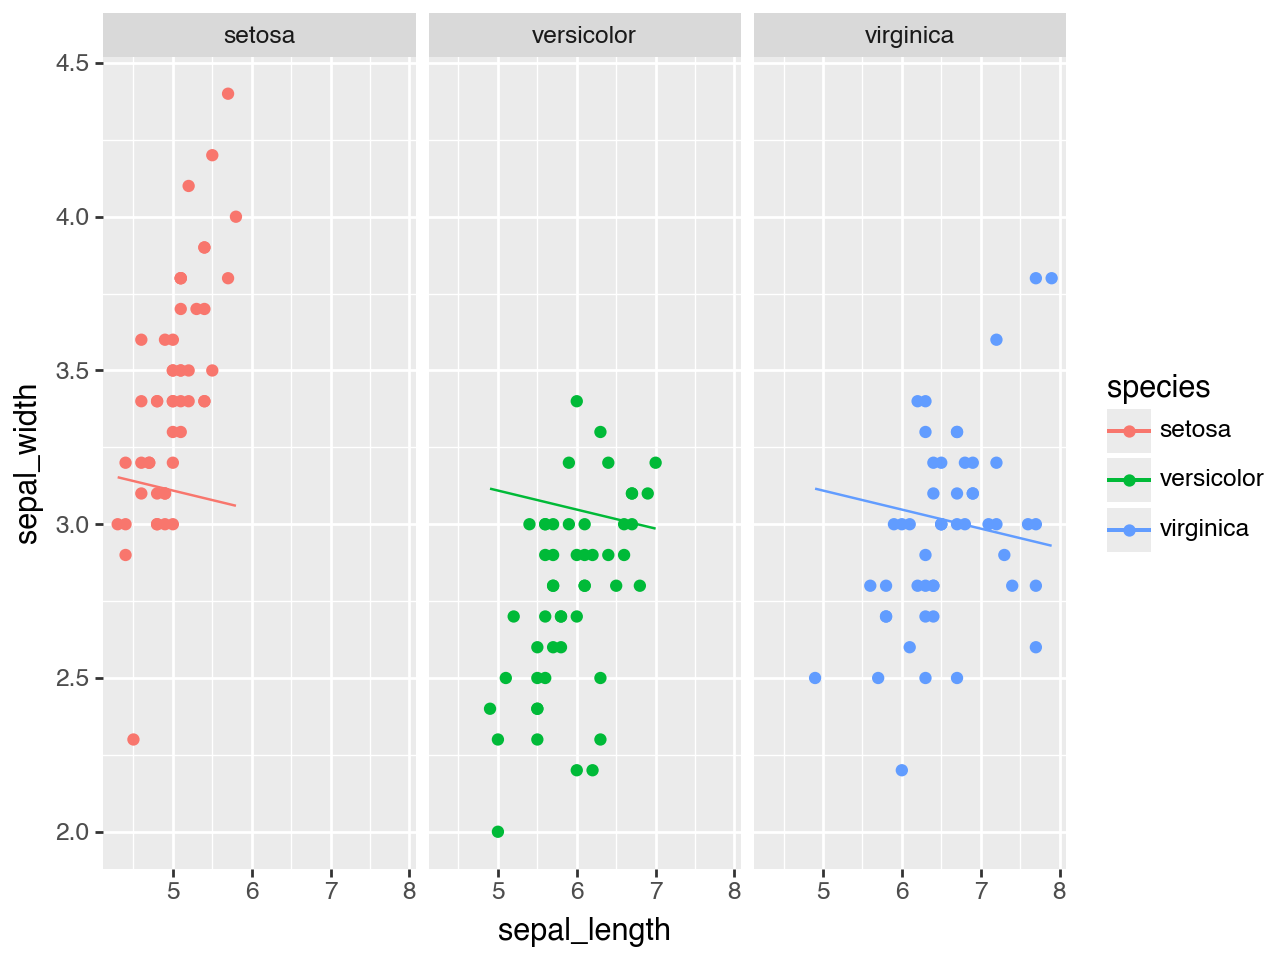

In [84]:
iris['base_prediction'] = iris_model1.predict(iris)

(
    ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
    geom_point() +
    geom_line(iris, aes(x = 'sepal_length', y = 'base_prediction')) + 
    facet_wrap('~species')
)

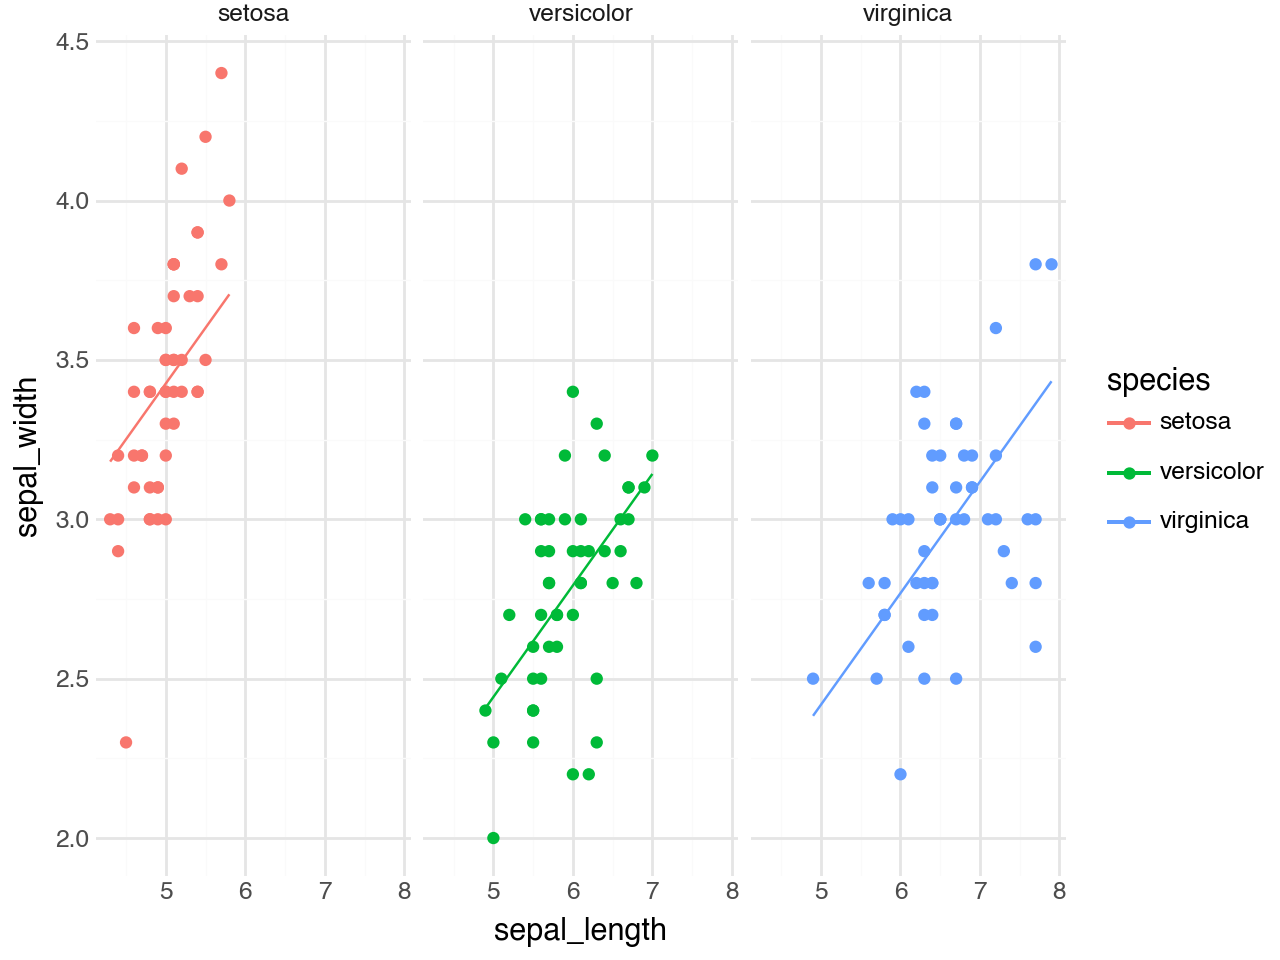

In [85]:
iris['species_intercept_predictions'] = iris_model2.predict(iris)
(
    ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
    geom_point() +
    geom_line(iris, aes(x = 'sepal_length', y = 'species_intercept_predictions')) +
    facet_wrap('species') +
    theme_minimal()
)

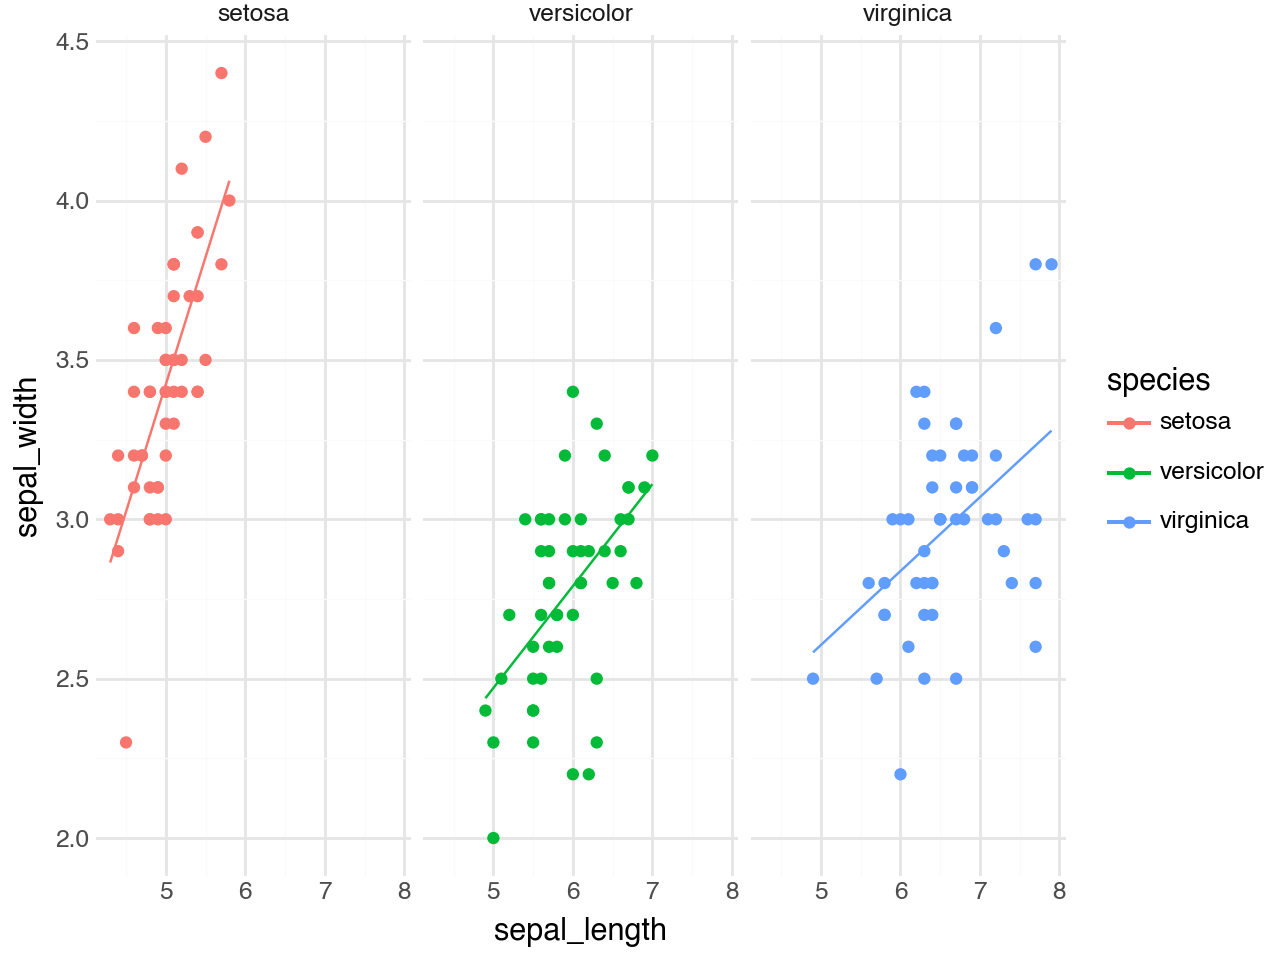

In [86]:
iris['species_intercept_slope_predictions'] = iris_model3.predict(iris)

(
    ggplot(iris, aes(x='sepal_length', y='sepal_width', color='species')) +
    geom_point() +
    geom_line(iris, aes(x = 'sepal_length', y = 'species_intercept_slope_predictions')) +
    facet_wrap('species') +
    theme_minimal()
)

4. Use anova to test if the second model is a better model than the base and also if the third model is
better than the second. Suppose all the assumptions of linear regression hold.

In [88]:
anova_result = anova_lm(iris_model1, iris_model3)
anova_result

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,148.0,27.915656,0.0,NaN,NaN,NaN
1,144.0,10.679969,4.0,17.235688,58.097995,4.107409e-29


$H_0$: adding species info does not improve the model

Conclusion: F statistic is big, p value < 0.05, we reject Ho. Therefore, adding species info does improve
the model.

In [89]:
anova_result = anova_lm(iris_model2, iris_model3)
anova_result

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,146.0,12.193134,0.0,NaN,NaN,NaN
1,144.0,10.679969,2.0,1.513165,10.201145,0.000072
